### Appendix A: Python Code for Data Cleaning and Exploratory Data Analysis (EDA)

The following code was utilized to clean the microdata, handle missing values, and generate the correlation heatmap (Figure 1) and cross-tabulations (Table 1).

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
file_path = '../data/raw/findex_microdata_2025_labelled_update112425.csv' 

print("Loading data...")
df = pd.read_csv(file_path)
print(f"Data loaded successfully! Shape: {df.shape}")

Loading data...
Data loaded successfully! Shape: (144090, 199)


In [28]:
# 2. Data Cleaning
print("\n--- Starting Data Cleaning ---")
# Drop rows where the target variable is missing
df = df.dropna(subset=['dig_account'])

# Fill missing values for demographic features
# (Median for continuous 'age', Mode for categorical variables)
df['age'] = df['age'].fillna(df['age'].median())
df['inc_q'] = df['inc_q'].fillna(df['inc_q'].mode()[0])
df['educ'] = df['educ'].fillna(df['educ'].mode()[0])
df['internet_use'] = df['internet_use'].fillna(df['internet_use'].mode()[0])

print("Data cleaning complete. Checking for missing values in key columns:")
print(df[['age', 'female', 'inc_q', 'educ', 'internet_use', 'dig_account']].isnull().sum())


--- Starting Data Cleaning ---
Data cleaning complete. Checking for missing values in key columns:
age             0
female          0
inc_q           0
educ            0
internet_use    0
dig_account     0
dtype: int64


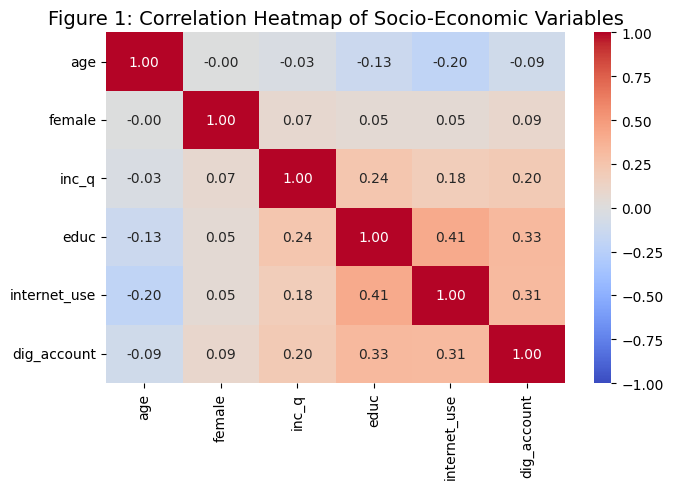

In [29]:
# 3. EDA - Correlation Heatmap (Figure 1)
plt.figure(figsize=(7, 5))
cols_to_corr =['age', 'female', 'inc_q', 'educ', 'internet_use', 'dig_account']
corr_matrix = df[cols_to_corr].corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Figure 1: Correlation Heatmap of Socio-Economic Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# 4. EDA - Cross-Tabulation (Table 1)
crosstab_result = pd.crosstab(
    index=df['inc_q'],
    columns=df['dig_account'],
    normalize='index' # Shows percentages across the row
) * 100

crosstab_result.index =['Quintile 1 (Poorest)', 'Quintile 2', 'Quintile 3', 'Quintile 4', 'Quintile 5 (Richest)']
crosstab_result.columns =['No Digital Account (%)', 'Has Digital Account (%)']

print("\n--- Table 1: Cross-Tabulation of Income Quintile vs. Digital Account Ownership ---")
display(crosstab_result.round(2))


--- Table 1: Cross-Tabulation of Income Quintile vs. Digital Account Ownership ---


,No Digital Account (%),Has Digital Account (%)
Quintile 1 (Poorest),65.65,34.35
Quintile 2,58.52,41.48
Quintile 3,52.73,47.27
Quintile 4,46.53,53.47
Quintile 5 (Richest),36.51,63.49


### Appendix B: Python Code for Logistic Regression and Odds Ratios

The following code was utilized to address RQ3, generate the classification metrics (Table 2), and extract the specific odds ratios (Table 3).

In [31]:
#Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score

In [32]:
# 1. Define Features (X) and Target (y)
X = df[['age', 'female', 'inc_q', 'educ', 'internet_use']]
y = df['dig_account']

In [22]:
# 2. Feature Engineering: Scale the continuous 'age' variable
# (This ensures 'age' doesn't artificially skew the model compared to categorical variables like 1-5)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled['age'] = scaler.fit_transform(X[['age']])

In [33]:
# 3. Train-Test Split (80% Training data, 20% Testing data)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [34]:
# 4. Initialize and Train the Model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train); # Semicolon suppresses HTML output

In [37]:
print("--- Starting Predictive Modelling (Logistic Regression) ---\n")
# 5. Evaluate the Model (Table 2)
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) # How many true adopters did we successfully find?

print("--- Preliminary Model Evaluation (Table 2 in Report) ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Recall (Sensitivity): {recall * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Starting Predictive Modelling (Logistic Regression) ---

--- Preliminary Model Evaluation (Table 2 in Report) ---
Accuracy: 67.57%
Recall (Sensitivity): 70.43%

Classification Report:
               precision    recall  f1-score   support

         0.0       0.69      0.65      0.67     10384
         1.0       0.66      0.70      0.68     10207

    accuracy                           0.68     20591
   macro avg       0.68      0.68      0.68     20591
weighted avg       0.68      0.68      0.68     20591



In [39]:
# 6. Extract Odds Ratios (Table 3)
# This explains exactly HOW MUCH a feature impacts the odds of adopting digital banking.
odds_ratios = np.exp(log_model.coef_[0])

odds_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0],
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

print("\n--- Table 3: Extracted Odds Ratios ---")
display(odds_df.round(3))


--- Table 3: Extracted Odds Ratios ---


,Feature,Coefficient,Odds Ratio
4,internet_use,0.961,2.614
3,educ,0.739,2.095
1,female,0.273,1.314
2,inc_q,0.182,1.200
0,age,-0.062,0.940
